In [64]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.datasets import load_breast_cancer
from sklearn.pipeline import make_pipeline, Pipeline
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family']='Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False

##  Sklearn `load_breast_cancer` 데이터셋 

`sklearn.datasets.load_breast_cancer` 함수로 로드한 데이터셋은 유방암 진단을 위한 **이진 분류(Binary Classification)** 데이터셋입니다. `as_frame=True` 옵션을 사용했기 때문에, 데이터는 Pandas DataFrame 형태로 로드되며, 이는 딕셔너리 형태의 `Bunch` 객체 내에 다양한 속성으로 저장됩니다.

주요 속성(Attributes)과 해당 속성의 의미는 다음과 같습니다.

| 속성명 | Type (as_frame=True 시) | 설명 |
| :--- | :--- | :--- |
| `data` | `pandas.DataFrame` | **특징(Feature) 데이터**입니다. 각 행은 하나의 샘플(세포 핵 관찰 기록)을 나타내며, 총 569개의 샘플이 있습니다. 열은 30개의 특징을 나타냅니다. |
| `target` | `pandas.Series` | **분류 목표(Target) 변수**입니다. 각 샘플에 대한 진단 결과(레이블)를 나타냅니다. 0 또는 1의 값을 가집니다. |
| `frame` | `pandas.DataFrame` | `data`와 `target`을 하나의 DataFrame으로 결합한 형태입니다. 질문에서 요청하신 `cancer['frame']`이 바로 이 전체 DataFrame입니다. (총 569행, 31열) |
| `target_names` | `numpy.ndarray` | `target` 레이블(0, 1)이 의미하는 바의 이름입니다. 일반적으로 **`['malignant', 'benign']`** 순서로 되어 있습니다. |
| `feature_names` | `numpy.ndarray` | `data` DataFrame의 컬럼(열) 이름이 되는 30개의 특징 이름입니다. |
| `DESCR` | `str` | 데이터셋에 대한 전체 설명입니다. 데이터 출처, 속성 정보, 요약 통계 등을 포함합니다. |

---

###  특징(Feature) 설명 (`feature_names`)

이 데이터셋의 특징은 세포핵의 이미지에서 계산된 10가지 특성(예: 반지름, 질감, 둘레, 면적 등)을 기반으로 하며, 각 특성에 대해 **평균(mean)**, **표준 오차(standard error - se)**, **가장 큰 값(worst/largest)**의 3가지 측정값이 제공되어 총 $10 \times 3 = 30$개의 특징이 구성됩니다.

| 특징 그룹 | 접미사 | 설명 |
| :--- | :--- | :--- |
| **평균** | `mean` | 각 특성의 평균값입니다. (예: `mean radius`) |
| **표준 오차** | `se` | 각 특성의 표준 오차입니다. (예: `radius error`) |
| **최대/가장 큰 값** | `worst` | 각 특성의 가장 큰(worst) 값, 또는 극한 값의 평균입니다. (예: `worst radius`) |

**10가지 기본 특성:**

1.  **Radius (반지름):** 핵의 평균 거리
2.  **Texture (질감):** 표면의 회색조 값의 표준 편차
3.  **Perimeter (둘레):** 핵의 둘레
4.  **Area (면적):** 핵의 면적
5.  **Smoothness (평활도):** 반경 길이의 변화
6.  **Compactness (조밀도):** 둘레 제곱 / 면적 - 1.0
7.  **Concavity (오목함):** 윤곽선 오목한 부분의 심각도
8.  **Concave points (오목점):** 윤곽선 오목한 부분의 수
9.  **Symmetry (대칭):** 핵의 대칭성
10. **Fractal dimension (프랙탈 차원):** 윤곽선의 복잡도

---

###  타겟(Target) 설명 (`target` 및 `target_names`)

`target` 컬럼은 분류하려는 목표 변수이며, 유방 종양의 진단 결과를 나타냅니다.

* **`target` 값 0:** **Malignant (악성)** - 암입니다.
* **`target` 값 1:** **Benign (양성)** - 암이 아닙니다.

이 데이터셋은 0을 악성(Malignant)으로, 1을 양성(Benign)으로 레이블링하고 있다는 점을 유의해야 합니다.

`cancer['frame']`에는 이 30개의 특징 컬럼과 마지막에 `target` 컬럼이 모두 포함되어 있습니다.


In [112]:
cancer = load_breast_cancer(as_frame=True)
df = cancer['frame']
df

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,0
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,0
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,0
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,0


In [141]:
df.corr()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
mean radius,1.000000,0.323782,0.997855,0.987357,0.170581,0.506124,0.676764,0.822529,0.147741,-0.311631,...,0.297008,0.965137,0.941082,0.119616,0.413463,0.526911,0.744214,0.163953,0.007066,-0.730029
mean texture,0.323782,1.000000,0.329533,0.321086,-0.023389,0.236702,0.302418,0.293464,0.071401,-0.076437,...,0.912045,0.358040,0.343546,0.077503,0.277830,0.301025,0.295316,0.105008,0.119205,-0.415185
mean perimeter,0.997855,0.329533,1.000000,0.986507,0.207278,0.556936,0.716136,0.850977,0.183027,-0.261477,...,0.303038,0.970387,0.941550,0.150549,0.455774,0.563879,0.771241,0.189115,0.051019,-0.742636
mean area,0.987357,0.321086,0.986507,1.000000,0.177028,0.498502,0.685983,0.823269,0.151293,-0.283110,...,0.287489,0.959120,0.959213,0.123523,0.390410,0.512606,0.722017,0.143570,0.003738,-0.708984
mean smoothness,0.170581,-0.023389,0.207278,0.177028,1.000000,0.659123,0.521984,0.553695,0.557775,0.584792,...,0.036072,0.238853,0.206718,0.805324,0.472468,0.434926,0.503053,0.394309,0.499316,-0.358560
mean compactness,0.506124,0.236702,0.556936,0.498502,0.659123,1.000000,0.883121,0.831135,0.602641,0.565369,...,0.248133,0.590210,0.509604,0.565541,0.865809,0.816275,0.815573,0.510223,0.687382,-0.596534
mean concavity,0.676764,0.302418,0.716136,0.685983,0.521984,0.883121,1.000000,0.921391,0.500667,0.336783,...,0.299879,0.729565,0.675987,0.448822,0.754968,0.884103,0.861323,0.409464,0.514930,-0.696360
mean concave points,0.822529,0.293464,0.850977,0.823269,0.553695,0.831135,0.921391,1.000000,0.462497,0.166917,...,0.292752,0.855923,0.809630,0.452753,0.667454,0.752399,0.910155,0.375744,0.368661,-0.776614
mean symmetry,0.147741,0.071401,0.183027,0.151293,0.557775,0.602641,0.500667,0.462497,1.000000,0.479921,...,0.090651,0.219169,0.177193,0.426675,0.473200,0.433721,0.430297,0.699826,0.438413,-0.330499
mean fractal dimension,-0.311631,-0.076437,-0.261477,-0.283110,0.584792,0.565369,0.336783,0.166917,0.479921,1.000000,...,-0.051269,-0.205151,-0.231854,0.504942,0.458798,0.346234,0.175325,0.334019,0.767297,0.012838


```text
과제
=================
1.정규화 하기
2. train ,test  나누기
3. train, test 정확도구하기
4. train, test confusion matrix 와 heatmap 구하기
------------
pipeline을 이용하여 학습하기
1. train, test 정확도구하기
2. train, test confusion matrix 와 heatmap 구하기


In [113]:
x_data = df.iloc[:, :-1].values
y_data = df.iloc[:, [-1]].values

In [114]:
x_data

array([[1.799e+01, 1.038e+01, 1.228e+02, ..., 2.654e-01, 4.601e-01,
        1.189e-01],
       [2.057e+01, 1.777e+01, 1.329e+02, ..., 1.860e-01, 2.750e-01,
        8.902e-02],
       [1.969e+01, 2.125e+01, 1.300e+02, ..., 2.430e-01, 3.613e-01,
        8.758e-02],
       ...,
       [1.660e+01, 2.808e+01, 1.083e+02, ..., 1.418e-01, 2.218e-01,
        7.820e-02],
       [2.060e+01, 2.933e+01, 1.401e+02, ..., 2.650e-01, 4.087e-01,
        1.240e-01],
       [7.760e+00, 2.454e+01, 4.792e+01, ..., 0.000e+00, 2.871e-01,
        7.039e-02]], shape=(569, 30))

In [115]:
y_data

array([[0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [1],
       [1],
       [1],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [1],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [1],
       [0],
       [1],
       [1],
       [1],
       [1],
       [1],
       [0],
       [0],
       [1],
       [0],
       [0],
       [1],
       [1],
       [1],
       [1],
       [0],
       [1],
       [0],
       [0],
       [1],
       [1],
       [1],
       [1],
       [0],
       [1],
       [0],
       [0],
       [1],
       [0],
       [1],
       [0],
       [0],
       [1],
       [1],
       [1],
       [0],
    

In [116]:
# 1.정규화 하기
scaleF = MinMaxScaler()
x_dataN = scaleF.fit_transform(x_data)
x_dataN

array([[0.52103744, 0.0226581 , 0.54598853, ..., 0.91202749, 0.59846245,
        0.41886396],
       [0.64314449, 0.27257355, 0.61578329, ..., 0.63917526, 0.23358959,
        0.22287813],
       [0.60149557, 0.3902604 , 0.59574321, ..., 0.83505155, 0.40370589,
        0.21343303],
       ...,
       [0.45525108, 0.62123774, 0.44578813, ..., 0.48728522, 0.12872068,
        0.1519087 ],
       [0.64456434, 0.66351031, 0.66553797, ..., 0.91065292, 0.49714173,
        0.45231536],
       [0.03686876, 0.50152181, 0.02853984, ..., 0.        , 0.25744136,
        0.10068215]], shape=(569, 30))

In [117]:
# 2. train ,test  나누기
x_train, x_test, y_train, y_test = train_test_split(x_dataN, y_data, 
                                                    test_size=0.3, stratify=y_data)

In [118]:
# 3. train, test 정확도 구하기
model = LogisticRegression(max_iter=500, verbose=True)
model.fit(x_train, y_train)

c:\Python310\lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,500
,multi_class,'deprecated'


In [123]:
model.score(x_train, y_train) 

0.9623115577889447

In [127]:
pred = model.predict(x_train)
pred

array([1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0,
       0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1,
       0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1,
       1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1,
       0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0,
       1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1,
       1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0,
       1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1,
       1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1,
       1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1,
       1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1,
       1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0,
       1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1,

In [129]:
pred == y_train.reshape(-1)

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True, False,
       False,  True,  True,  True,  True, False,  True,  True,  True,
        True,  True,  True,  True, False,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True, False,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True, False,  True,  True,  True, False,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True, False,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,

In [76]:
from sklearn.metrics import accuracy_score

In [131]:
accuracy_score(y_train, pred)

0.9623115577889447

In [130]:
np.mean(pred == y_train.reshape(-1)) 

np.float64(0.9623115577889447)

In [78]:
model.score(x_test,y_test)

0.9649122807017544

In [132]:
from sklearn.metrics import confusion_matrix

In [135]:
# 4. train, test confusion matrix 와 heatmap 구하기
pred_t = model.predict(x_train) # 예측값
c = confusion_matrix(y_train, pred_t) # (실제값, 예측값)
c

array([[134,  14],
       [  1, 249]])

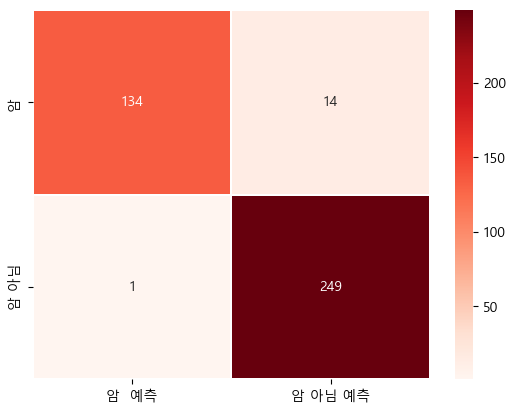

In [137]:
import seaborn as sb
sb.heatmap(c, annot=True, fmt='d', linewidths=0.2, cmap='Reds',
        xticklabels=['암  예측','암 아님 예측'], 
        yticklabels=['암 ', '암 아님'])
plt.show()

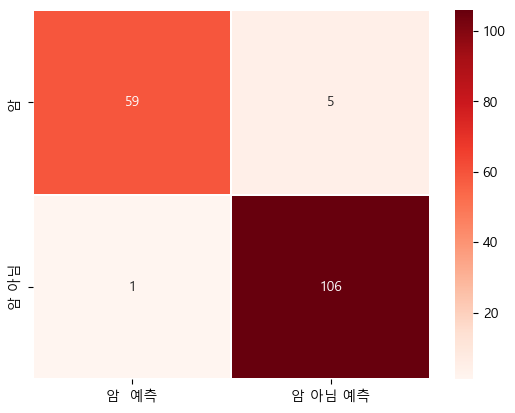

In [ ]:
pred_tt = model.predict(x_test) # 예측값
c = confusion_matrix(y_test, pred_tt) # (실제값, 예측값)

sb.heatmap(c, annot=True, fmt='d', linewidths=0.2, cmap='Reds',
                xticklabels=['암  예측','암 아님 예측'], 
                yticklabels=['암 ', '암 아님'])
plt.show() 

pipeline을 이용하여 학습하기
1. train, test 정확도 구하기
2. train, test confusion matrix 와 heatmap 구하기

In [83]:
x_data = df.iloc[:, :-1].values
y_data = df.iloc[:, -1].values

x_train, x_test, y_train, y_test = train_test_split(x_data, y_data, 
                                                    test_size=0.3, stratify=y_data)

In [84]:
model_pipeline = make_pipeline(MinMaxScaler(), LogisticRegression(max_iter=500))
model_pipeline.fit(x_train,y_train)

,steps,"[('minmaxscaler', ...), ('logisticregression', ...)]"
,transform_input,None
,memory,None
,verbose,False
,feature_range,"(0, ...)"
,copy,True
,clip,False
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0


In [85]:
model_pipeline.score(x_train,y_train)

0.9698492462311558

In [86]:
model_pipeline.score(x_test, y_test)

0.9707602339181286

In [87]:
pred_c = model_pipeline.predict(x_train) # 예측값
cn = confusion_matrix(y_train, pred_c) # (실제값, 예측값)
cn

array([[137,  11],
       [  1, 249]])

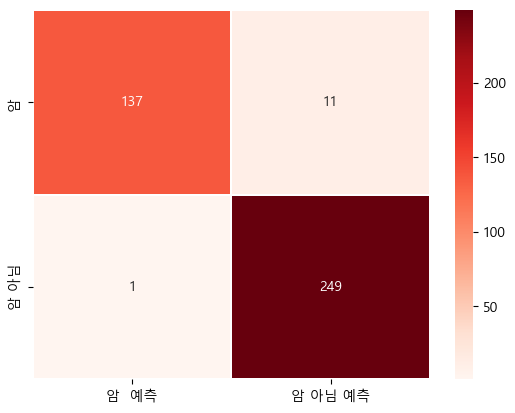

In [140]:
sb.heatmap(cn, annot=True, fmt='d', linewidths=0.2, cmap='Reds',
                xticklabels=['암  예측','암 아님 예측'], 
                yticklabels=['암 ', '암 아님'])
plt.show()

In [89]:
pred_cc = model_pipeline.predict(x_test) # 예측값
c_n = confusion_matrix(y_test, pred_cc) # (실제값, 예측값)
c_n

array([[ 59,   5],
       [  0, 107]])

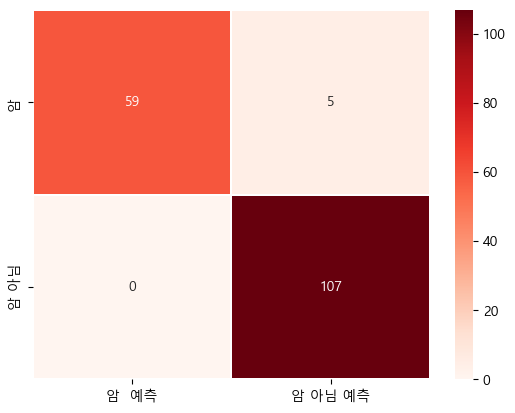

In [139]:
sb.heatmap(c_n, annot=True, fmt='d', linewidths=0.2, cmap='Reds',
                xticklabels=['암  예측','암 아님 예측'], 
                yticklabels=['암 ', '암 아님'])
plt.show()